# eWaterCycle containerized model

This notebook is to showcase/test the containerized model.

We import the LeakyBucket model:

In [1]:
from src.ewatercycle_swmm.model import SWMM

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


To be able to initialize the model, we need forcing data:

In [2]:
from ewatercycle.base.parameter_set import ParameterSet
import ewatercycle
from pathlib import Path
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

swmm_dir = Path.home() / "ewatercycle-swmm"
swmm_dir.mkdir(parents=True, exist_ok=True)

input_file = swmm_dir / "example.inp"

parameters = ParameterSet(
    name="SWMM_parameter_files",
    directory=swmm_dir,
    config=Path(input_file),
    target_model='swmm',
)

In [3]:
!rm -rf swmm_20*

Now we can start the model. The `LeakyBucket` class uses a container hosted on the Github container registry.

Alternatively, you can start the model using a local container. For this you would modify the command as such:

```py
from ewatercycle.container import ContainerImage
LeakyBucket(forcing=forcing, bmi_image=ContainerImage("local_image:latest"))
```

In [4]:
model = SWMM(parameter_set=parameters)
cfg_file, _ = model.setup()

In [5]:
model.initialize(cfg_file)

In [6]:
model.bmi.get_component_name()

'SWMM'

To test the model, we'll make a hydrograph:

In [7]:
n_sc    = model.bmi.get_grid_size(0)
n_nodes = model.bmi.get_grid_size(1)
n_links = model.bmi.get_grid_size(2)

times       = []
sc_runoff   = []
node_depth  = []
node_flood  = []
link_flow   = []

while model.time < model.end_time:
    times.append(model.bmi.get_current_time())
    sc_runoff.append( model.bmi.get_value("subcatchment_runoff", np.empty(n_sc)).copy()    )
    node_depth.append(model.bmi.get_value("node_depth",          np.empty(n_nodes)).copy() )
    node_flood.append(model.bmi.get_value("node_flooding",       np.empty(n_nodes)).copy() )
    link_flow.append( model.bmi.get_value("link_flow",           np.empty(n_links)).copy() )
    model.update()

# Convert to arrays and a pandas time axis
hr         = pd.to_datetime([datetime.datetime.fromtimestamp(t, tz=datetime.timezone.utc) for t in times])
sc_runoff  = np.array(sc_runoff)   # shape: (n_steps, n_sc)
node_depth = np.array(node_depth)  # shape: (n_steps, n_nodes)
node_flood = np.array(node_flood)
link_flow  = np.array(link_flow)   # shape: (n_steps, n_links)

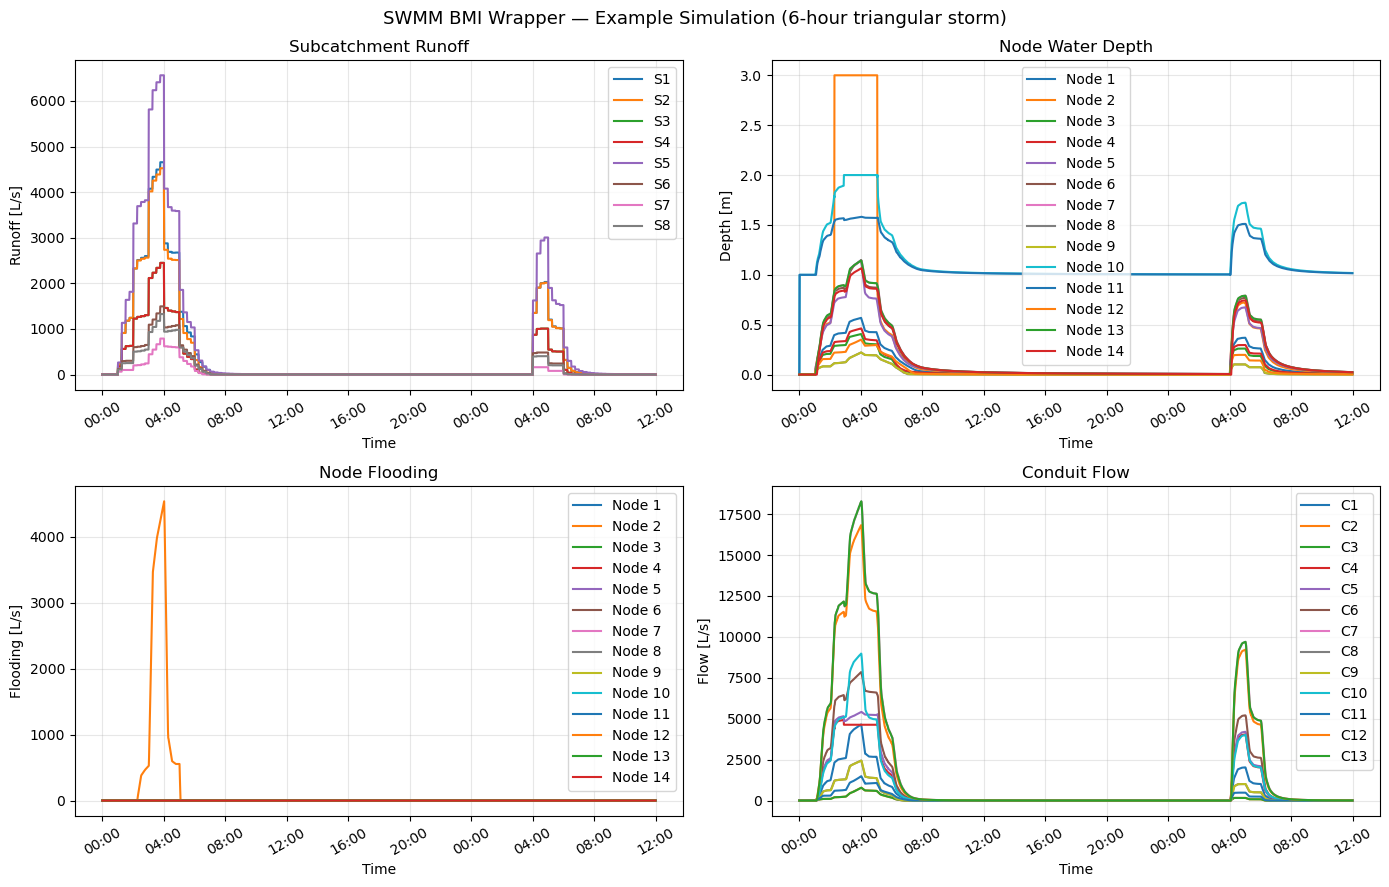

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("SWMM BMI Wrapper — Example Simulation (6-hour triangular storm)", fontsize=13)

sc_labels   = [f"S{i+1}" for i in range(n_sc)]
node_labels = [f"Node {i+1}" for i in range(n_nodes)]
link_labels = [f"C{i+1}" for i in range(n_links)]

# Subcatchment runoff  [m3/s → L/s for readability]
ax = axes[0, 0]
for i, lbl in enumerate(sc_labels):
    ax.plot(hr, sc_runoff[:, i] * 1000, label=lbl)
ax.set_ylabel("Runoff [L/s]")
ax.set_title("Subcatchment Runoff")
ax.legend()

# Node water depth
ax = axes[0, 1]
for i, lbl in enumerate(node_labels):
    ax.plot(hr, node_depth[:, i], label=lbl)
ax.set_ylabel("Depth [m]")
ax.set_title("Node Water Depth")
ax.legend()

# Node flooding
ax = axes[1, 0]
for i, lbl in enumerate(node_labels):
    ax.plot(hr, node_flood[:, i] * 1000, label=lbl)
ax.set_ylabel("Flooding [L/s]")
ax.set_title("Node Flooding")
ax.legend()

# Link flow
ax = axes[1, 1]
for i, lbl in enumerate(link_labels):
    ax.plot(hr, link_flow[:, i] * 1000, label=lbl)
ax.set_ylabel("Flow [L/s]")
ax.set_title("Conduit Flow")
ax.legend()

for ax in axes.flat:
    ax.set_xlabel("Time")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
# plt.savefig("swmm_bmi_results.png", dpi=100, bbox_inches="tight")
plt.show()

To make sure that the container running the model is nicely shut down and doesn't keep running in the background (taking up resources) we need to 'finalize' it.

In [9]:
model.finalize()

In [10]:
EXTERNAL_INFLOW_M3S = 0.05  # 50 L/s injected at every node (on top of storm runoff)

model2 = SWMM(parameter_set=parameters)
cfg_file, _ = model2.setup()

model2.initialize(cfg_file)

In [11]:
n_nodes2 = model2.bmi.get_grid_size(1)
n_links2 = model2.bmi.get_grid_size(2)
times2      = []
node_depth2 = []
node_flood2 = []
link_flow2  = []

while model2.bmi.get_current_time() < model2.bmi.get_end_time():
    model2.bmi.set_value(
        "node_lateral_inflow",
        np.full(n_nodes2, EXTERNAL_INFLOW_M3S)
    )
    model2.bmi.update()
    times2.append(model2.bmi.get_current_time())
    node_depth2.append(model2.bmi.get_value("node_depth",    np.empty(n_nodes2)).copy())
    node_flood2.append(model2.bmi.get_value("node_flooding", np.empty(n_nodes2)).copy())
    link_flow2.append( model2.bmi.get_value("link_flow",     np.empty(n_links2)).copy())

node_depth2 = np.array(node_depth2)
node_flood2 = np.array(node_flood2)
link_flow2  = np.array(link_flow2)
hr2 = pd.to_datetime([datetime.datetime.fromtimestamp(t, tz=datetime.timezone.utc) for t in times2])

print("External inflow run complete.")
print(f"Peak outfall flow (built-in) : {link_flow[:, -1].max()*1000:.1f} L/s")
print(f"Peak outfall flow (+ inflow) : {link_flow2[:, -1].max()*1000:.1f} L/s")

External inflow run complete.
Peak outfall flow (built-in) : 18282.2 L/s
Peak outfall flow (+ inflow) : 18803.0 L/s


In [12]:
model2.finalize()